# Bias Audit: Face Detection Fairness on FairFace

## What This Notebook Does

This notebook runs a **fairness audit** of two face detection systems:
- **DeepFace** (with RetinaFace backend)
- **ArcFace** (via InsightFace's SCRFD detector)

We test whether these systems detect faces equally well across **7 racial groups** using the FairFace validation dataset (10,954 face images).

### Why this matters
If a face detection system used in crime scene investigation misses faces of certain groups more often, those people are **erased from the evidentiary record** — a harm we call *documentary erasure*.

### What we measure
1. **Detection failure rate** per racial group (did the system find the face?)
2. **Confidence scores** per racial group (how confident was the detection?)
3. **Statistical significance** via chi-square test
4. **Pairwise comparisons** with Bonferroni correction

### Output
- CSV of all detection results
- Publication-quality bar charts with confidence intervals
- LaTeX-ready tables for the paper
- Chi-square test results

---
**Runtime:** Set to **GPU** (Runtime → Change runtime type → T4 GPU)  
**Estimated time:** ~45-90 minutes for full audit on 1,400 balanced images

## Step 0: Install Dependencies

We need:
- `deepface` — wraps RetinaFace detector
- `insightface` — provides SCRFD detector + ArcFace
- `onnxruntime-gpu` — GPU acceleration for InsightFace
- `albumentations` — image transformations for brightness reduction
- Standard data science stack (pandas, scipy, matplotlib, seaborn)

In [1]:
!pip install deepface insightface onnxruntime-gpu albumentations -q
print("All dependencies installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 15.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.3/270.3 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 74.1 MB/s eta 0:00:00
All dependencies installed.


## Step 1: Mount Google Drive & Set Paths

Upload these files to your Google Drive:
1. `fairface_label_val.csv` — the validation labels
2. The **unzipped** image folder (should contain `val/` subfolder with .jpg files)

**Edit the paths below** to match your Drive folder structure.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# >>> EDIT THESE PATHS TO MATCH YOUR GOOGLE DRIVE <<<
# ============================================================
BASE_DIR = "/content/drive/MyDrive/bias_audit"  # your project folder
LABELS_PATH = f"{BASE_DIR}/fairface_label_val.csv"  # validation labels
IMAGES_DIR = f"{BASE_DIR}/fairface-img-margin025-trainval/"  # image root
# Images should be at: {IMAGES_DIR}/val/1.jpg, {IMAGES_DIR}/val/2.jpg, etc.

OUTPUT_DIR = f"{BASE_DIR}/outputs"
FIGURES_DIR = f"{BASE_DIR}/outputs/figures"

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"Base directory: {BASE_DIR}")
print(f"Labels path: {LABELS_PATH}")
print(f"Images directory: {IMAGES_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Mounted at /content/drive
Base directory: /content/drive/MyDrive/bias_audit
Labels path: /content/drive/MyDrive/bias_audit/fairface_label_val.csv
Images directory: /content/drive/MyDrive/bias_audit/fairface-img-margin025-trainval/
Output directory: /content/drive/MyDrive/bias_audit/outputs


## Step 2: Load and Explore the FairFace Dataset

FairFace provides face images labeled with:
- **race** (7 categories): Black, East Asian, Indian, Latino_Hispanic, Middle Eastern, Southeast Asian, White
- **gender**: Male, Female
- **age**: 9 brackets from 0-2 to 70+

We use the **validation set** (10,954 images) as our test set.  
We are NOT training anything — we are testing pre-existing detection systems.

In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load validation labels
df = pd.read_csv(LABELS_PATH)

print(f"Total validation images: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nRace distribution:")
print(df['race'].value_counts().sort_index())
print(f"\nGender distribution:")
print(df['gender'].value_counts())
print(f"\nFirst 5 rows:")
df.head()

Total validation images: 10954

Columns: ['file', 'age', 'gender', 'race', 'service_test']

Race distribution:
race
Black              1556
East Asian         1550
Indian             1516
Latino_Hispanic    1623
Middle Eastern     1209
Southeast Asian    1415
White              2085
Name: count, dtype: int64

Gender distribution:
gender
Male      5792
Female    5162
Name: count, dtype: int64

First 5 rows:


,file,age,gender,race,service_test
0,val/1.jpg,3-9,Male,East Asian,False
1,val/2.jpg,50-59,Female,East Asian,True
2,val/3.jpg,30-39,Male,White,True
3,val/4.jpg,20-29,Female,Latino_Hispanic,True
4,val/5.jpg,20-29,Male,Southeast Asian,False


## Step 3: Sample a Balanced Test Set

We sample **200 images per racial group** for a balanced audit.  
Total: 200 × 7 = **1,400 images**.

Why 200? It gives us enough statistical power to detect a 10 percentage-point
difference between groups at α = 0.05 with >95% power. Any fewer and we risk
missing real disparities; many more and the audit takes too long.

We set a random seed (42) so the exact same images are selected every time
the notebook runs — this is essential for **reproducibility**.

In [4]:
SAMPLES_PER_GROUP = 200
RANDOM_SEED = 42

# Sample 200 images per race, balanced
sampled = df.groupby('race', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), SAMPLES_PER_GROUP), random_state=RANDOM_SEED)
).reset_index(drop=True)

print(f"Sampled {len(sampled)} images total")
print(f"\nDistribution (should be {SAMPLES_PER_GROUP} per group):")
print(sampled['race'].value_counts().sort_index())

# Verify a few image paths exist
sample_path = os.path.join(IMAGES_DIR, sampled['file'].iloc[0])
print(f"\nSample image path: {sample_path}")
print(f"File exists: {os.path.exists(sample_path)}")

# If the path doesn't work, try adjusting — the 'file' column has 'val/1.jpg'
# Your images might be at a different subfolder level
if not os.path.exists(sample_path):
    print("\n⚠️  Image not found! Check your IMAGES_DIR path.")
    print(f"Looking for: {sample_path}")
    # Try to find where images actually are
    for root, dirs, files in os.walk(IMAGES_DIR):
        jpg_files = [f for f in files if f.endswith('.jpg')][:3]
        if jpg_files:
            print(f"Found images at: {root}")
            print(f"Example files: {jpg_files}")
            break

Sampled 1400 images total

Distribution (should be 200 per group):
race
Black              200
East Asian         200
Indian             200
Latino_Hispanic    200
Middle Eastern     200
Southeast Asian    200
White              200
Name: count, dtype: int64

Sample image path: /content/drive/MyDrive/bias_audit/fairface-img-margin025-trainval/val/10528.jpg
File exists: True


## Step 4: Initialize Face Detection Systems

We initialize two systems:

### System 1: DeepFace (RetinaFace backend)
- **What it is:** A popular Python library for face analysis
- **Detector:** RetinaFace — a single-stage, multi-task face detector
- **Why we test it:** Widely used in research and industry; default choice for many applications

### System 2: InsightFace (SCRFD detector)
- **What it is:** The detection component of the InsightFace library (which also provides ArcFace recognition)
- **Detector:** SCRFD — Sample and Computation Redistribution for Face Detection
- **Why we test it:** State-of-the-art accuracy; feeds the ArcFace recognition pipeline

Both are used with **default thresholds** — because a real-world forensic deployment
would likely use out-of-the-box settings.

In [5]:
# Initialize InsightFace
from insightface.app import FaceAnalysis

print("Initializing InsightFace (SCRFD detector)...")
insightface_app = FaceAnalysis(
    name='buffalo_l',
    providers=['CUDAExecutionProvider', 'CPUExecutionProvider']
)
insightface_app.prepare(ctx_id=0)
print("✓ InsightFace ready")

# DeepFace initializes lazily on first call, so we do a warmup
from deepface import DeepFace
import cv2

print("Warming up DeepFace (RetinaFace backend)...")
# Create a dummy image for warmup
dummy = np.zeros((224, 224, 3), dtype=np.uint8)
try:
    DeepFace.extract_faces(dummy, detector_backend='retinaface', enforce_detection=False)
except:
    pass
print("✓ DeepFace ready")

print("\nBoth detection systems initialized.")

Initializing InsightFace (SCRFD detector)...
download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:02<00:00, 98465.16KB/s]


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with o

Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /root/.deepface/weights/retinaface.h5
100%|██████████| 119M/119M [00:00<00:00, 449MB/s] 


✓ DeepFace ready

Both detection systems initialized.


## Step 5: Define Detection Functions

Each function takes an image and returns:
- `detected` (True/False) — did the system find a face?
- `confidence` (float) — how confident was the detection?

Since FairFace images are **pre-cropped face images**, a well-performing
detector should find a face in nearly every image. Any failures represent
genuine detection shortcomings — exactly what we want to measure.

In [6]:
def detect_deepface(image_bgr):
    """
    Run DeepFace with RetinaFace backend.

    Args:
        image_bgr: OpenCV BGR image (numpy array)
    Returns:
        (detected: bool, confidence: float)
    """
    try:
        results = DeepFace.extract_faces(
            img_path=image_bgr,
            detector_backend='retinaface',
            enforce_detection=False
        )
        if results and len(results) > 0:
            conf = results[0].get('confidence', 0)
            if conf is not None and conf > 0:
                return True, float(conf)
        return False, 0.0
    except Exception as e:
        return False, 0.0


def detect_insightface(image_bgr, app):
    """
    Run InsightFace (SCRFD detector).

    Args:
        image_bgr: OpenCV BGR image (numpy array)
        app: initialized FaceAnalysis instance
    Returns:
        (detected: bool, confidence: float)
    """
    try:
        faces = app.get(image_bgr)
        if faces and len(faces) > 0:
            conf = float(faces[0].det_score)
            return True, conf
        return False, 0.0
    except Exception as e:
        return False, 0.0


def reduce_brightness(image_bgr, factor=0.5):
    """
    Reduce image brightness to simulate dim forensic conditions.

    Args:
        image_bgr: OpenCV BGR image
        factor: 0.5 means 50% darker
    Returns:
        Darkened image
    """
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    hsv[:, :, 2] *= factor
    hsv[:, :, 2] = np.clip(hsv[:, :, 2], 0, 255)
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)


# Quick test on one image
test_path = os.path.join(IMAGES_DIR, sampled['file'].iloc[0])
if os.path.exists(test_path):
    test_img = cv2.imread(test_path)
    d1, c1 = detect_deepface(test_img)
    d2, c2 = detect_insightface(test_img, insightface_app)
    print(f"Test image: {test_path}")
    print(f"  DeepFace:    detected={d1}, confidence={c1:.4f}")
    print(f"  InsightFace: detected={d2}, confidence={c2:.4f}")
    print("\n✓ Detection functions working.")
else:
    print(f"⚠️ Test image not found: {test_path}")
    print("Fix IMAGES_DIR before proceeding.")

Test image: /content/drive/MyDrive/bias_audit/fairface-img-margin025-trainval/val/10528.jpg
  DeepFace:    detected=True, confidence=1.0000
  InsightFace: detected=False, confidence=0.0000

✓ Detection functions working.


## Step 6: Run the Full Bias Audit

This is the main experiment. For each of the 1,400 sampled images, we:

1. Load the image
2. Run both detectors on the **original** (standard lighting)
3. Reduce brightness by 50% to simulate dim forensic conditions
4. Run both detectors on the **dimmed** version
5. Log all results with the subject's race, gender, and age

This produces **5,600 detection trials** total:  
1,400 images × 2 lighting conditions × 2 detection systems

**Estimated time: 45–90 minutes on T4 GPU.**

In [7]:
import time

BRIGHTNESS_FACTOR = 0.5  # 50% reduction for dim condition

results = []
errors = []
total = len(sampled)
start_time = time.time()

print(f"Starting audit on {total} images...")
print(f"Each image tested: 2 detectors × 2 lighting = 4 trials")
print(f"Total trials: {total * 4}")
print("=" * 60)

for idx, row in sampled.iterrows():
    img_path = os.path.join(IMAGES_DIR, row['file'])

    # Load image
    img = cv2.imread(img_path)
    if img is None:
        errors.append(img_path)
        continue

    # Create dimmed version
    img_dim = reduce_brightness(img, BRIGHTNESS_FACTOR)

    # Common metadata for this image
    meta = {
        'file': row['file'],
        'race': row['race'],
        'gender': row['gender'],
        'age': row['age']
    }

    # Test all 4 combinations: (2 systems) × (2 lighting conditions)
    for condition, image in [('standard', img), ('dim', img_dim)]:
        # DeepFace
        df_det, df_conf = detect_deepface(image)
        results.append({
            **meta,
            'condition': condition,
            'system': 'DeepFace (RetinaFace)',
            'detected': df_det,
            'confidence': df_conf
        })

        # InsightFace
        if_det, if_conf = detect_insightface(image, insightface_app)
        results.append({
            **meta,
            'condition': condition,
            'system': 'InsightFace (SCRFD)',
            'detected': if_det,
            'confidence': if_conf
        })

    # Progress update every 100 images
    count = len(results) // 4
    if count % 100 == 0 and count > 0:
        elapsed = time.time() - start_time
        rate = count / elapsed
        remaining = (total - count) / rate if rate > 0 else 0
        print(f"  [{count}/{total}] {elapsed:.0f}s elapsed, ~{remaining:.0f}s remaining")

elapsed = time.time() - start_time
print(f"\n{'=' * 60}")
print(f"Audit complete in {elapsed:.0f} seconds ({elapsed/60:.1f} minutes)")
print(f"Total detection trials: {len(results)}")
print(f"Image load errors: {len(errors)}")

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Save raw results
results_path = os.path.join(OUTPUT_DIR, 'detection_results.csv')
results_df.to_csv(results_path, index=False)
print(f"\nResults saved to: {results_path}")
print(f"\nQuick look at results:")
results_df.head(8)

Starting audit on 1400 images...
Each image tested: 2 detectors × 2 lighting = 4 trials
Total trials: 5600
  [100/1400] 105s elapsed, ~1371s remaining
  [200/1400] 209s elapsed, ~1253s remaining
  [300/1400] 313s elapsed, ~1148s remaining
  [400/1400] 415s elapsed, ~1038s remaining
  [500/1400] 518s elapsed, ~933s remaining
  [600/1400] 623s elapsed, ~830s remaining
  [700/1400] 729s elapsed, ~729s remaining
  [800/1400] 833s elapsed, ~625s remaining
  [900/1400] 942s elapsed, ~523s remaining
  [1000/1400] 1049s elapsed, ~419s remaining
  [1100/1400] 1153s elapsed, ~315s remaining
  [1200/1400] 1256s elapsed, ~209s remaining
  [1300/1400] 1358s elapsed, ~104s remaining
  [1400/1400] 1463s elapsed, ~0s remaining

Audit complete in 1463 seconds (24.4 minutes)
Total detection trials: 5600
Image load errors: 0

Results saved to: /content/drive/MyDrive/bias_audit/outputs/detection_results.csv

Quick look at results:


,file,race,gender,age,condition,system,detected,confidence
0,val/10528.jpg,Black,Male,3-9,standard,DeepFace (RetinaFace),True,1.0
1,val/10528.jpg,Black,Male,3-9,standard,InsightFace (SCRFD),False,0.0
2,val/10528.jpg,Black,Male,3-9,dim,DeepFace (RetinaFace),True,1.0
3,val/10528.jpg,Black,Male,3-9,dim,InsightFace (SCRFD),False,0.0
4,val/955.jpg,Black,Male,20-29,standard,DeepFace (RetinaFace),True,1.0
5,val/955.jpg,Black,Male,20-29,standard,InsightFace (SCRFD),False,0.0
6,val/955.jpg,Black,Male,20-29,dim,DeepFace (RetinaFace),True,1.0
7,val/955.jpg,Black,Male,20-29,dim,InsightFace (SCRFD),False,0.0


## Step 7: Compute Detection Failure Rates by Race

Now we answer the core question: **do failure rates differ across racial groups?**

We compute failure rate = (missed faces) / (total faces) for each group,
broken down by detection system and lighting condition.

In [8]:
# Compute failure rates for each (system, condition, race) combination
summary = results_df.groupby(['system', 'condition', 'race']).agg(
    total=('detected', 'count'),
    detected=('detected', 'sum'),
    mean_confidence=('confidence', 'mean')
).reset_index()

summary['missed'] = summary['total'] - summary['detected']
summary['failure_rate'] = summary['missed'] / summary['total']
summary['failure_pct'] = (summary['failure_rate'] * 100).round(2)

# Display results
for system in results_df['system'].unique():
    for condition in ['standard', 'dim']:
        subset = summary[(summary['system'] == system) & (summary['condition'] == condition)]
        subset = subset.sort_values('race')
        print(f"\n{'=' * 60}")
        print(f"  {system} — {condition.upper()} lighting")
        print(f"{'=' * 60}")
        for _, row in subset.iterrows():
            bar = '█' * int(row['failure_pct'])
            print(f"  {row['race']:20s}  {row['failure_pct']:6.2f}%  "
                  f"({row['missed']:.0f}/{row['total']:.0f})  "
                  f"conf={row['mean_confidence']:.3f}  {bar}")


  DeepFace (RetinaFace) — STANDARD lighting
  Black                   0.00%  (0/200)  conf=0.999  
  East Asian              0.00%  (0/200)  conf=1.000  
  Indian                  0.00%  (0/200)  conf=0.999  
  Latino_Hispanic         0.00%  (0/200)  conf=1.000  
  Middle Eastern          0.00%  (0/200)  conf=0.999  
  Southeast Asian         0.00%  (0/200)  conf=1.000  
  White                   0.00%  (0/200)  conf=1.000  

  DeepFace (RetinaFace) — DIM lighting
  Black                   0.50%  (1/200)  conf=0.994  
  East Asian              0.00%  (0/200)  conf=1.000  
  Indian                  0.00%  (0/200)  conf=0.999  
  Latino_Hispanic         0.00%  (0/200)  conf=1.000  
  Middle Eastern          0.00%  (0/200)  conf=1.000  
  Southeast Asian         0.00%  (0/200)  conf=1.000  
  White                   0.00%  (0/200)  conf=1.000  

  InsightFace (SCRFD) — STANDARD lighting
  Black                  99.00%  (198/200)  conf=0.006  ██████████████████████████████████████████████

## Step 8: Statistical Tests — Chi-Square + Pairwise Comparisons

### What we're testing
- **Null hypothesis (H₀):** Detection failure is independent of race — all groups fail at the same rate
- **Alternative hypothesis (H₁):** Detection failure rates differ by race

### Method
1. **Chi-square test of independence** on the full 2×7 contingency table (detected/missed × 7 races)
2. **Fisher's exact test** for pairwise comparisons (each race vs. White as reference)
3. **Bonferroni correction** — divide α by 6 (number of pairwise comparisons) to control for multiple testing

### Why Bonferroni?
When you run 6 separate tests, the chance of getting at least one false positive is
~26%, not 5%. Bonferroni fixes this by requiring p < 0.05/6 = 0.0083 for each individual test.

In [9]:
from scipy import stats

def wilson_ci(p, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0.0, 0.0
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    spread = z * np.sqrt((p * (1 - p) / n) + z**2 / (4 * n**2)) / denom
    return max(0, center - spread), min(1, center + spread)


# Store all analysis results
all_analyses = {}

for system in results_df['system'].unique():
    for condition in ['standard', 'dim']:
        key = f"{system} | {condition}"
        subset = results_df[
            (results_df['system'] == system) &
            (results_df['condition'] == condition)
        ]

        # --- Chi-Square Test ---
        ct = pd.crosstab(
            subset['detected'].map({True: 'Detected', False: 'Missed'}),
            subset['race']
        )
        chi2, p_val, dof, expected = stats.chi2_contingency(ct)

        print(f"\n{'=' * 70}")
        print(f"  {key}")
        print(f"{'=' * 70}")
        print(f"  Chi-square statistic: χ² = {chi2:.4f}")
        print(f"  Degrees of freedom:   df = {dof}")
        print(f"  P-value:              p  = {p_val:.8f}")

        if p_val < 0.001:
            print(f"  Result: *** HIGHLY SIGNIFICANT (p < 0.001) ***")
        elif p_val < 0.01:
            print(f"  Result: ** SIGNIFICANT (p < 0.01) **")
        elif p_val < 0.05:
            print(f"  Result: * SIGNIFICANT (p < 0.05) *")
        else:
            print(f"  Result: NOT significant (p ≥ 0.05)")

        # --- Failure rates with Wilson CIs ---
        races = sorted(subset['race'].unique())
        failure_data = {}

        print(f"\n  {'Race':20s}  {'Fail%':>7s}  {'95% CI':>15s}  {'Missed':>8s}  {'Total':>6s}")
        print(f"  {'-'*65}")

        for race in races:
            group = subset[subset['race'] == race]
            n_total = len(group)
            n_missed = len(group[~group['detected']])
            rate = n_missed / n_total if n_total > 0 else 0
            ci_lo, ci_hi = wilson_ci(rate, n_total)
            failure_data[race] = {
                'rate': rate, 'n_total': n_total, 'n_missed': n_missed,
                'ci_low': ci_lo, 'ci_high': ci_hi
            }
            print(f"  {race:20s}  {rate*100:6.2f}%  [{ci_lo*100:5.2f}%, {ci_hi*100:5.2f}%]  {n_missed:>6d}  {n_total:>6d}")

        # --- Pairwise: each race vs White (Bonferroni-corrected) ---
        ref_race = 'White'
        n_comparisons = len(races) - 1
        bonferroni_alpha = 0.05 / n_comparisons

        ref_group = subset[subset['race'] == ref_race]
        ref_det = ref_group['detected'].sum()
        ref_miss = len(ref_group) - ref_det

        pairwise_results = {}
        print(f"\n  Pairwise vs {ref_race} (Bonferroni α = {bonferroni_alpha:.4f}):")

        for race in races:
            if race == ref_race:
                continue
            comp_group = subset[subset['race'] == race]
            comp_det = comp_group['detected'].sum()
            comp_miss = len(comp_group) - comp_det

            table_2x2 = np.array([
                [ref_det, ref_miss],
                [comp_det, comp_miss]
            ])

            _, pw_p = stats.fisher_exact(table_2x2)
            sig = '***' if pw_p < bonferroni_alpha else 'n.s.'
            pairwise_results[race] = {'p': pw_p, 'sig': pw_p < bonferroni_alpha}
            print(f"    {ref_race} vs {race:20s}: p = {pw_p:.6f}  {sig}")

        all_analyses[key] = {
            'chi2': chi2, 'p_value': p_val, 'dof': dof,
            'failure_data': failure_data,
            'pairwise': pairwise_results,
            'contingency_table': ct
        }

print(f"\n\n{'=' * 70}")
print("  All statistical analyses complete.")
print(f"{'=' * 70}")


  DeepFace (RetinaFace) | standard
  Chi-square statistic: χ² = 0.0000
  Degrees of freedom:   df = 0
  P-value:              p  = 1.00000000
  Result: NOT significant (p ≥ 0.05)

  Race                    Fail%           95% CI    Missed   Total
  -----------------------------------------------------------------
  Black                   0.00%  [ 0.00%,  1.88%]       0     200
  East Asian              0.00%  [ 0.00%,  1.88%]       0     200
  Indian                  0.00%  [ 0.00%,  1.88%]       0     200
  Latino_Hispanic         0.00%  [ 0.00%,  1.88%]       0     200
  Middle Eastern          0.00%  [ 0.00%,  1.88%]       0     200
  Southeast Asian         0.00%  [ 0.00%,  1.88%]       0     200
  White                   0.00%  [ 0.00%,  1.88%]       0     200

  Pairwise vs White (Bonferroni α = 0.0083):
    White vs Black               : p = 1.000000  n.s.
    White vs East Asian          : p = 1.000000  n.s.
    White vs Indian              : p = 1.000000  n.s.
    White vs L

## Step 9: Publication-Quality Visualizations

Generate bar charts showing failure rates by race for each system and condition,
with 95% Wilson confidence intervals. These go directly into the paper.

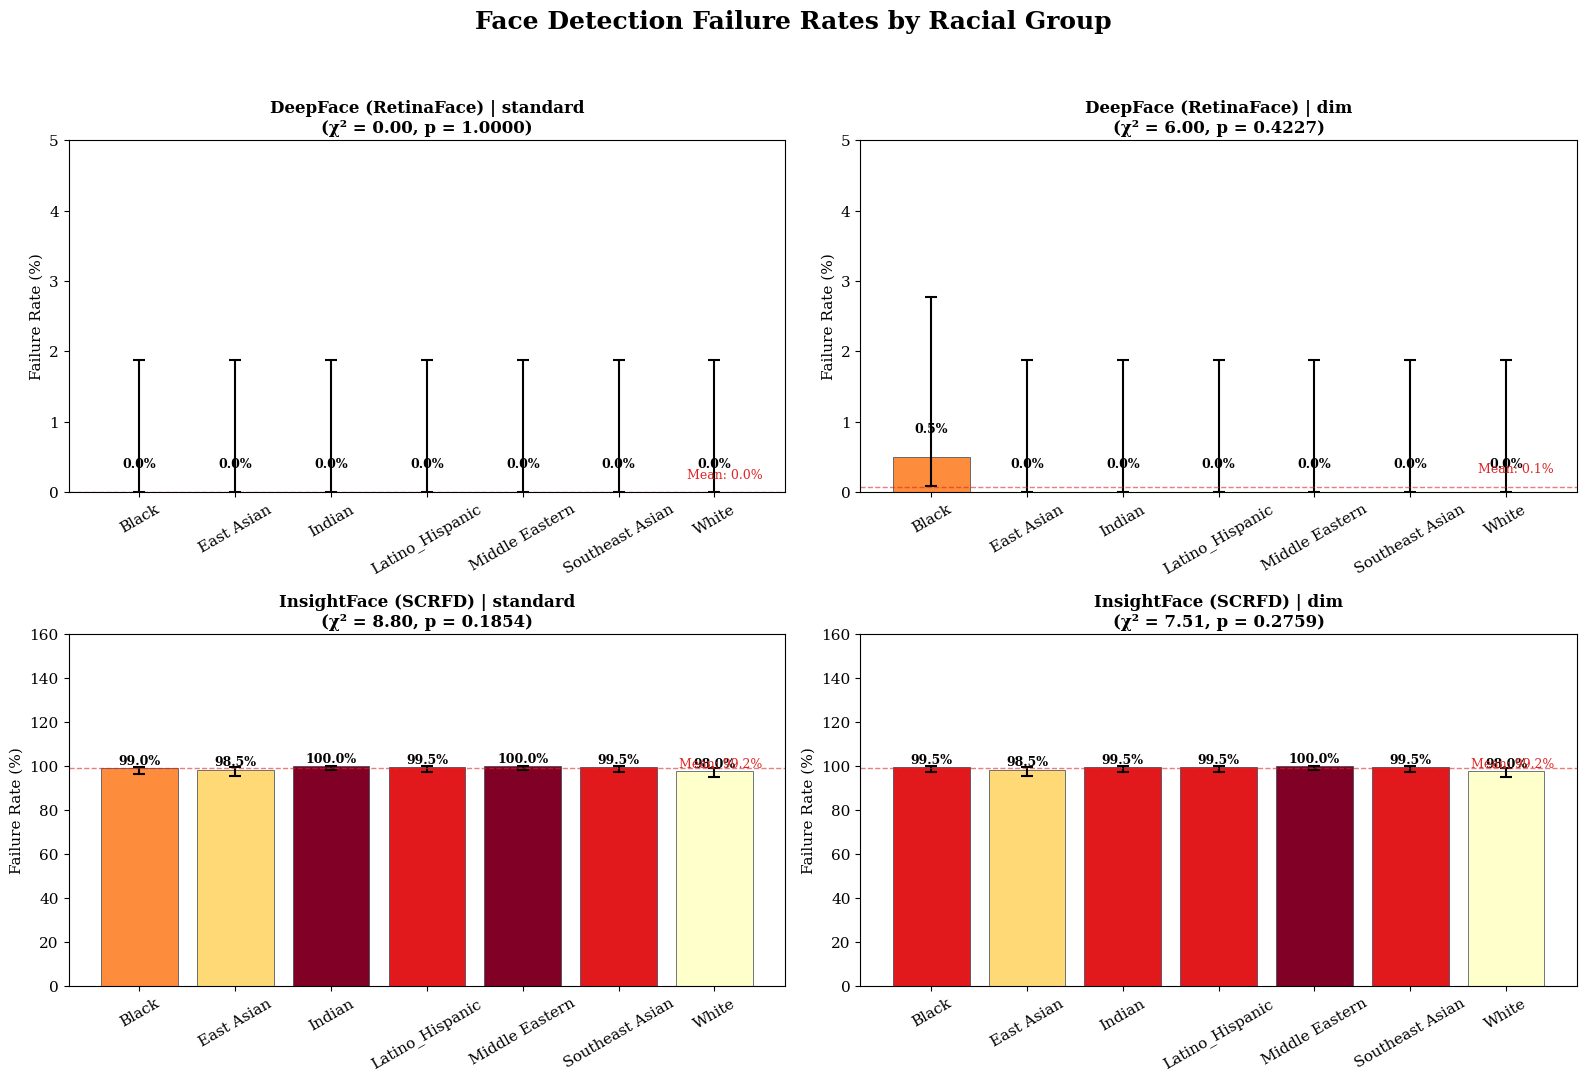


Figures saved to /content/drive/MyDrive/bias_audit/outputs/figures


In [11]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 11

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Face Detection Failure Rates by Racial Group',
             fontsize=18, fontweight='bold', y=0.98)

plot_keys = list(all_analyses.keys())

for i, key in enumerate(plot_keys):
    ax = axes[i // 2, i % 2]
    data = all_analyses[key]
    fd = data['failure_data']

    races = sorted(fd.keys())
    rates = [fd[r]['rate'] * 100 for r in races]
    ci_lo = [fd[r]['ci_low'] * 100 for r in races]
    ci_hi = [fd[r]['ci_high'] * 100 for r in races]
    yerr_lo = [r - lo for r, lo in zip(rates, ci_lo)]
    yerr_hi = [hi - r for r, hi in zip(rates, ci_hi)]

    # Color by failure rate (darker = higher failure)
    norm = plt.Normalize(vmin=min(rates), vmax=max(max(rates), 1))
    colors = plt.cm.YlOrRd(norm(np.array(rates)))

    bars = ax.bar(
        races, rates,
        yerr=[yerr_lo, yerr_hi],
        capsize=4, color=colors,
        edgecolor='#334155', linewidth=0.5,
        error_kw={'elinewidth': 1.5, 'capthick': 1.5, 'color': '#334155'}
    )

    # Labels on bars
    for bar, rate in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f'{rate:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Formatting
    p_str = f'p < 0.001' if data['p_value'] < 0.001 else f'p = {data["p_value"]:.4f}'
    ax.set_title(f"{key}\n(χ² = {data['chi2']:.2f}, {p_str})",
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Failure Rate (%)', fontsize=11)
    ax.set_ylim(0, max(max(rates) * 1.6, 5))
    ax.tick_params(axis='x', rotation=30)

    # Mean line
    mean_rate = np.mean(rates)
    ax.axhline(y=mean_rate, color='#DC2626', linestyle='--', alpha=0.6, linewidth=1)
    ax.text(len(races)-0.5, mean_rate + 0.2, f'Mean: {mean_rate:.1f}%',
            color='#DC2626', fontsize=9, ha='right')

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save in multiple formats
plt.savefig(os.path.join(FIGURES_DIR, 'failure_rates_by_race.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(FIGURES_DIR, 'failure_rates_by_race.pdf'), bbox_inches='tight')
plt.show()
print(f"\nFigures saved to {FIGURES_DIR}")

## Step 10: Confidence Score Analysis

Even when faces ARE detected, are the confidence scores lower for certain groups?
Lower confidence = more vulnerable to being dropped if the threshold changes.

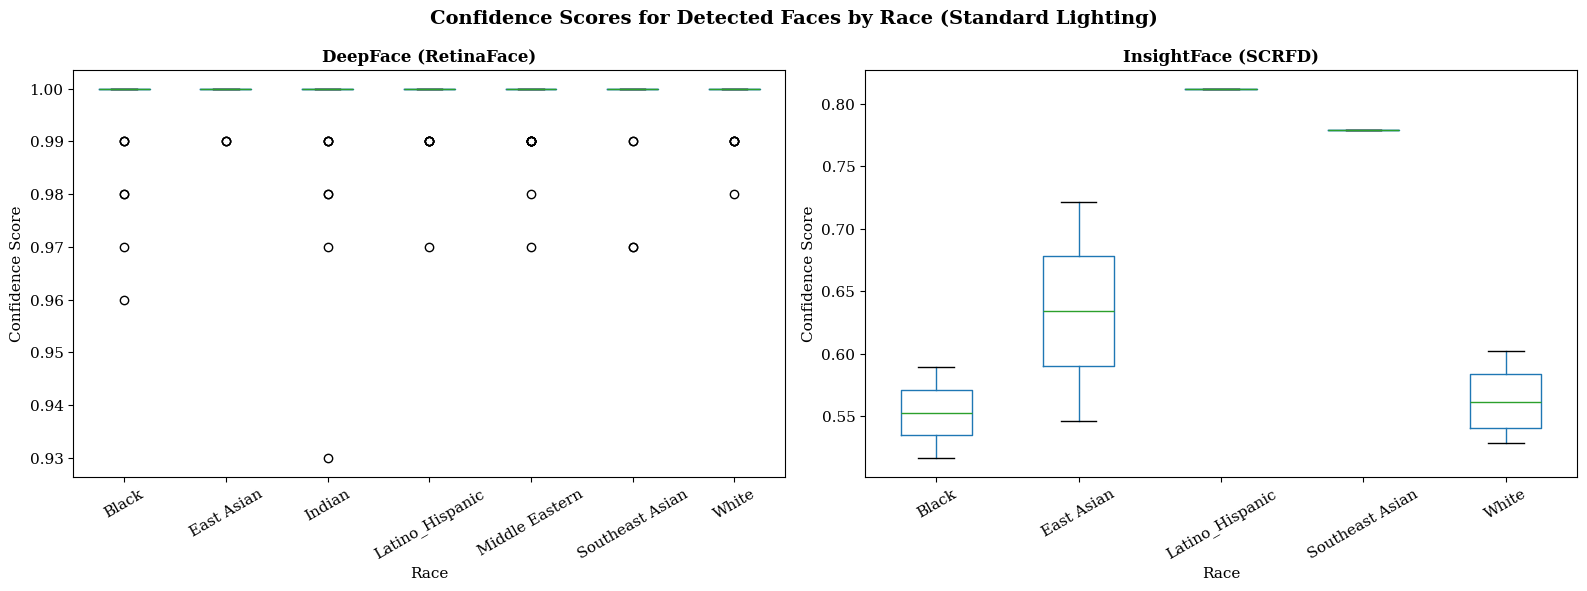


Mean Confidence Scores (standard lighting):
system           DeepFace (RetinaFace)  InsightFace (SCRFD)
race                                                       
Black                           0.9993               0.5528
East Asian                      0.9998               0.6342
Indian                          0.9991                  NaN
Latino_Hispanic                 0.9996               0.8123
Middle Eastern                  0.9993                  NaN
Southeast Asian                 0.9996               0.7789
White                           0.9996               0.5630


In [12]:
# Filter to only detected faces
detected_only = results_df[results_df['detected'] == True]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confidence Scores for Detected Faces by Race (Standard Lighting)',
             fontsize=14, fontweight='bold')

for i, system in enumerate(detected_only['system'].unique()):
    subset = detected_only[
        (detected_only['system'] == system) &
        (detected_only['condition'] == 'standard')
    ]

    ax = axes[i]
    subset.boxplot(column='confidence', by='race', ax=ax, grid=False)
    ax.set_title(system, fontsize=12, fontweight='bold')
    ax.set_xlabel('Race')
    ax.set_ylabel('Confidence Score')
    ax.tick_params(axis='x', rotation=30)
    plt.sca(ax)
    plt.title(system, fontsize=12, fontweight='bold')

fig.suptitle('Confidence Scores for Detected Faces by Race (Standard Lighting)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'confidence_by_race.png'), dpi=300, bbox_inches='tight')
plt.show()

# Print mean confidence by race for each system
print("\nMean Confidence Scores (standard lighting):")
pivot = detected_only[detected_only['condition'] == 'standard'].pivot_table(
    values='confidence', index='race', columns='system', aggfunc='mean'
)
print(pivot.round(4).to_string())

## Step 11: Export LaTeX Tables for the Paper

Generate tables formatted for direct insertion into the IEEE LaTeX paper.
Copy-paste these into the Results section of `paper.tex`.

In [13]:
def generate_latex_table(analysis, key, system_short):
    """Generate a LaTeX table for one system × condition."""
    fd = analysis['failure_data']
    races = sorted(fd.keys())

    # Short race labels for table
    short = {
        'Black': 'Blk', 'East Asian': 'E.As', 'Indian': 'Ind',
        'Latino_Hispanic': 'Lat', 'Middle Eastern': 'M.E',
        'Southeast Asian': 'SE.As', 'White': 'Wht'
    }

    header = ' & '.join([f'\\textbf{{{short.get(r, r)}}}' for r in races])
    rates = ' & '.join([f'{fd[r]["rate"]*100:.1f}' for r in races])
    counts = ' & '.join([f'{fd[r]["n_missed"]}/{fd[r]["n_total"]}' for r in races])

    chi2 = analysis['chi2']
    p = analysis['p_value']

    latex = f"""
% {key}
\\begin{{tabular}}{{lccccccc}}
\\toprule
& {header} \\\\
\\midrule
Failure \\% & {rates} \\\\
Missed/Total & {counts} \\\\
\\bottomrule
\\multicolumn{{8}}{{l}}{{$\\chi^2 = {chi2:.2f}$, $p = {p:.6f}$}} \\\\
\\end{{tabular}}
"""
    return latex


print("\n" + "=" * 60)
print("  LaTeX TABLES — Copy these into paper.tex")
print("=" * 60)

for key, analysis in all_analyses.items():
    latex = generate_latex_table(analysis, key, key.split(' | ')[0])
    print(latex)

# Also save to file
with open(os.path.join(OUTPUT_DIR, 'latex_tables.tex'), 'w') as f:
    for key, analysis in all_analyses.items():
        f.write(generate_latex_table(analysis, key, key.split(' | ')[0]))

print(f"\nTables also saved to {OUTPUT_DIR}/latex_tables.tex")


  LaTeX TABLES — Copy these into paper.tex

% DeepFace (RetinaFace) | standard
\begin{tabular}{lccccccc}
\toprule
& \textbf{Blk} & \textbf{E.As} & \textbf{Ind} & \textbf{Lat} & \textbf{M.E} & \textbf{SE.As} & \textbf{Wht} \\
\midrule
Failure \% & 0.0 & 0.0 & 0.0 & 0.0 & 0.0 & 0.0 & 0.0 \\
Missed/Total & 0/200 & 0/200 & 0/200 & 0/200 & 0/200 & 0/200 & 0/200 \\
\bottomrule
\multicolumn{8}{l}{$\chi^2 = 0.00$, $p = 1.000000$} \\
\end{tabular}


% DeepFace (RetinaFace) | dim
\begin{tabular}{lccccccc}
\toprule
& \textbf{Blk} & \textbf{E.As} & \textbf{Ind} & \textbf{Lat} & \textbf{M.E} & \textbf{SE.As} & \textbf{Wht} \\
\midrule
Failure \% & 0.5 & 0.0 & 0.0 & 0.0 & 0.0 & 0.0 & 0.0 \\
Missed/Total & 1/200 & 0/200 & 0/200 & 0/200 & 0/200 & 0/200 & 0/200 \\
\bottomrule
\multicolumn{8}{l}{$\chi^2 = 6.00$, $p = 0.422710$} \\
\end{tabular}


% InsightFace (SCRFD) | standard
\begin{tabular}{lccccccc}
\toprule
& \textbf{Blk} & \textbf{E.As} & \textbf{Ind} & \textbf{Lat} & \textbf{M.E} & \textbf{SE.A

## Step 12: Summary Report

Final summary of all findings, formatted for easy reference when writing the paper.

In [14]:
print("\n" + "=" * 70)
print("  BIAS AUDIT — FINAL SUMMARY")
print("=" * 70)
print(f"  Dataset:     FairFace validation set")
print(f"  Sample:      {len(sampled)} images ({SAMPLES_PER_GROUP} per group)")
print(f"  Groups:      {len(sampled['race'].unique())} racial categories")
print(f"  Systems:     DeepFace (RetinaFace), InsightFace (SCRFD)")
print(f"  Conditions:  Standard lighting + Dim (-50% brightness)")
print(f"  Total trials: {len(results_df)}")
print(f"  Random seed: {RANDOM_SEED}")

print(f"\n  KEY FINDINGS:")
print(f"  {'-' * 60}")

for key, analysis in all_analyses.items():
    fd = analysis['failure_data']
    rates = {r: fd[r]['rate']*100 for r in fd}
    max_race = max(rates, key=rates.get)
    min_race = min(rates, key=rates.get)

    sig = '***' if analysis['p_value'] < 0.001 else (
          '**' if analysis['p_value'] < 0.01 else (
          '*' if analysis['p_value'] < 0.05 else 'n.s.'))

    print(f"\n  {key}:")
    print(f"    Chi-square: χ²={analysis['chi2']:.2f}, p={analysis['p_value']:.6f} {sig}")
    print(f"    Highest failure: {max_race} ({rates[max_race]:.1f}%)")
    print(f"    Lowest failure:  {min_race} ({rates[min_race]:.1f}%)")
    print(f"    Disparity ratio: {rates[max_race]/max(rates[min_race], 0.1):.1f}×")

print(f"\n  {'-' * 60}")
print(f"  Files saved:")
print(f"    {OUTPUT_DIR}/detection_results.csv")
print(f"    {FIGURES_DIR}/failure_rates_by_race.png")
print(f"    {FIGURES_DIR}/failure_rates_by_race.pdf")
print(f"    {FIGURES_DIR}/confidence_by_race.png")
print(f"    {OUTPUT_DIR}/latex_tables.tex")
print(f"\n  >>> Next step: paste numbers into paper.tex <<<")
print("=" * 70)


  BIAS AUDIT — FINAL SUMMARY
  Dataset:     FairFace validation set
  Sample:      1400 images (200 per group)
  Groups:      7 racial categories
  Systems:     DeepFace (RetinaFace), InsightFace (SCRFD)
  Conditions:  Standard lighting + Dim (-50% brightness)
  Total trials: 5600
  Random seed: 42

  KEY FINDINGS:
  ------------------------------------------------------------

  DeepFace (RetinaFace) | standard:
    Chi-square: χ²=0.00, p=1.000000 n.s.
    Highest failure: Black (0.0%)
    Lowest failure:  Black (0.0%)
    Disparity ratio: 0.0×

  DeepFace (RetinaFace) | dim:
    Chi-square: χ²=6.00, p=0.422710 n.s.
    Highest failure: Black (0.5%)
    Lowest failure:  East Asian (0.0%)
    Disparity ratio: 5.0×

  InsightFace (SCRFD) | standard:
    Chi-square: χ²=8.80, p=0.185357 n.s.
    Highest failure: Indian (100.0%)
    Lowest failure:  White (98.0%)
    Disparity ratio: 1.0×

  InsightFace (SCRFD) | dim:
    Chi-square: χ²=7.51, p=0.275947 n.s.
    Highest failure: Middle Ea